In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build vocabs
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [4]:
block_size = 3 #context length. How many characters are used to predict the next one

def build_dataset(words):
    
    X, Y = [], [] #X input to NN, Y is label
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'---->', itos[ix])
            context = context[1:] + [ix] # sliding window

    X = torch.tensor(X)
    Y = torch.tensor(Y)    
    return X, Y


import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [5]:
n_embd = 10
n_hidden = 200
vocab_size = len(stoi)
vocab_size

27

In [6]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g) # each letter in alphabet + '.' has a 2 letter embedding

# Here we scale these down to avoid saturating tanh in the first hidden layer. 
# Saturating means we get lots of values at +-1. This leads to 0 gradient and therefore the node will never change value
W1 = torch.randn(block_size*n_embd, n_hidden, generator=g) * (5/3) / ((block_size*n_embd)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01

# for W2 and b2 we want these to be small such that are logits are small. The idea is just for the logits to be similar to each other initially.
# Initial loss should be log(num_outputs) as we assume each outcome is equally likely (1/num_outputs) so nll is log(num_outputs)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 
b2 = torch.randn(vocab_size, generator=g) * 0

# batch normalisation
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
n_params = sum(param.nelement() for param in parameters)

for param in parameters:
    param.requires_grad = True

n_params

12297

In [ ]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

        ix = torch.randint(0, Xtr.shape[0], (batch_size,))

        # forward pass
        emb = C[Xtr[ix]]
        embcat = emb.view(emb.shape[0], block_size*n_embd)
        hpreact = embcat @ W1 + b1

        # batch normalisation. 
        # we want our activations in the hidden layer to be gaussian.
        # This is because we dont want to saturate the tanh. And we dont want them to be 0 other wise our network isnt doing anything
        # Makes training easier when are gradients and acitivations are in a good window.
        # see google paper but equation is standard and easily differentiable
        bnmeani = hpreact.mean(0, keepdim=True)
        bnstdi = hpreact.std(0, keepdim=True)
        hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

        with torch.no_grad():
             bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
             bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Ytr[ix])

        # backwards pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        lr = 0.1 if i < 100000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad


        # track stats
        if i % 10000 == 0:
             print(f'{i:7d}/{max_steps:7d}: {loss.item():4f}')
        lossi.append(loss.log10().item())

        #break

      0/ 200000: 3.299537
  10000/ 200000: 2.318181
  20000/ 200000: 2.562196
  30000/ 200000: 2.562732
  40000/ 200000: 2.532264
  50000/ 200000: 2.393620
  60000/ 200000: 2.393403
  70000/ 200000: 2.279083
  80000/ 200000: 2.161966
  90000/ 200000: 1.856143
 100000/ 200000: 2.560622
 110000/ 200000: 2.108850
 120000/ 200000: 2.064014
 130000/ 200000: 2.162705
 140000/ 200000: 2.188181
 150000/ 200000: 1.949253
 160000/ 200000: 1.745169
 170000/ 200000: 1.828700
 180000/ 200000: 2.282427
 190000/ 200000: 2.241091


### Saturation of tanh

Looking at how to correctly initialise a neural network

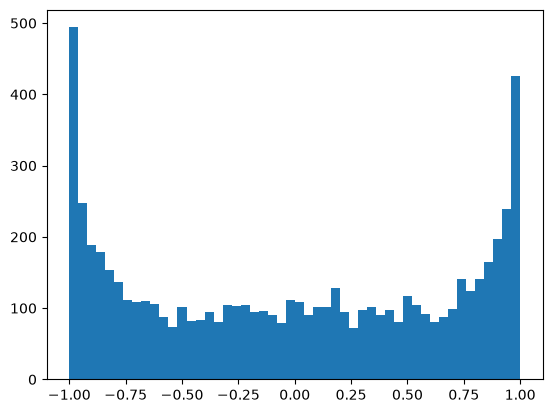

In [8]:
# Histogram of activation values in hidden layer
# Many of them are -1 or 1. This is due to the shape of tanh
# The issue here is that the grad will drop to 0 and (derivative = 1-tanh^2) and no further changes will be made
plt.hist(h.view(-1).tolist(),50);

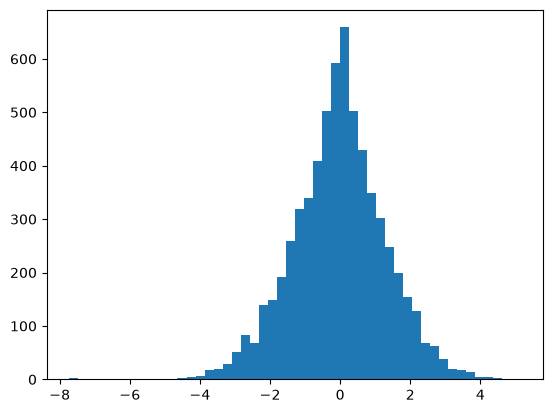

In [9]:
plt.hist(hpreact.view(-1).tolist(),50);

In [10]:
(torch.randn(10000) * 0.2).std()

tensor(0.1989)

tensor(-0.0141) tensor(0.9921)
tensor(-0.0050) tensor(0.9880)


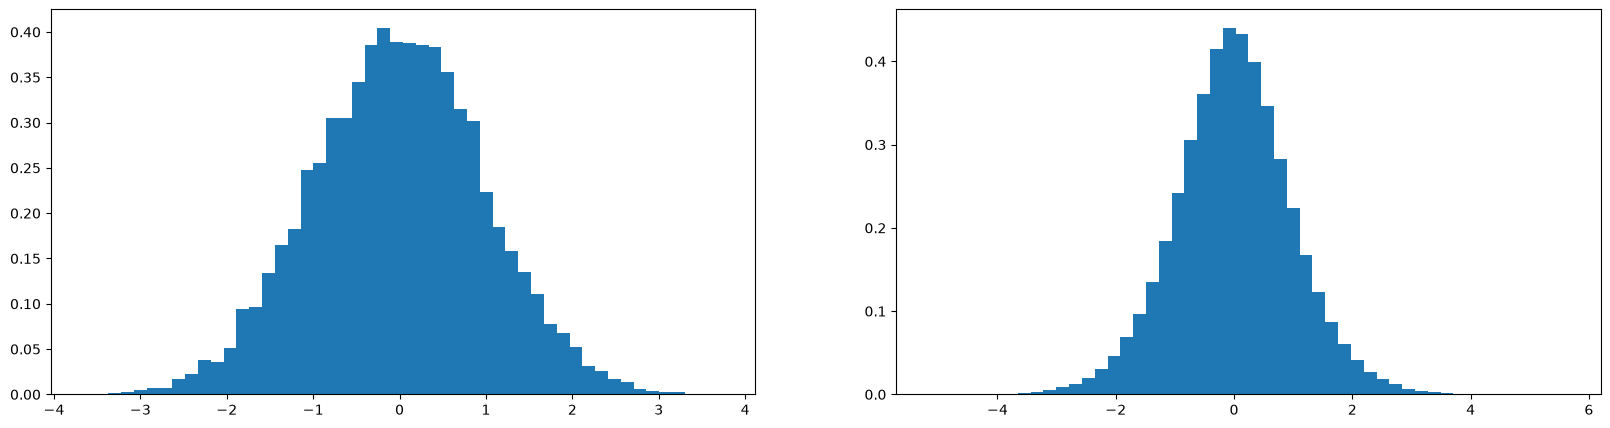

In [11]:
# Here we divide w by root(10) such that var(x) = var(y)
# var(y) = n * var(x) * var(w) using the fact x and w are iid and the linearity of variance
# var(x) = n * var(x) * var(w)
# var(w) = 1/n
# hence std(w) = 1 / root(n)
# https://docs.pytorch.org/docs/2.13/nn.init.html

x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density = True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density = True);


## evaluate

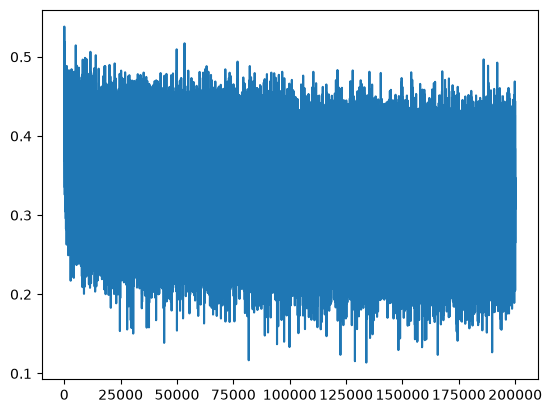

In [12]:
plt.plot(lossi)

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1 bias does nothing when we batch normalize
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066520929336548
val 2.1100261211395264


In [20]:
#sampling

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

chrishfatumilvifktrrixxthtllngcasskedricnbbdevelystifghrisskldurshchailvinsletgyhh.
matdi.
fengtth.
slustz.
vidhquiszefradiarisix.
khugbigsth.
stte.
xiz.
gtaelhastr.
shpadyb.
